In [ ]:
import numpy as np
import pandas as pd
from rdkit import Chem

avail1044 = pd.read_csv('../result/represent_fg1_fg2_1044.csv',usecols=['fg1_fg2','fg1_fg2_marked', 'avail0','canon_smarts']) #result2
avail1044['avail0'] = avail1044['avail0'].apply(Chem.CanonSmiles)


df = pd.read_csv('dpph_result-4-27.csv') #发生断键的数据
df[['rxn','inner_broken','outer_broken']]
s = Chem.CanonSmiles('O=P(C1=CC=CC=C1)(ON)C2=CC=CC=C2')

df['inner_broken'] = df['inner_broken'].apply(eval)
df['outer_broken'] = df['outer_broken'].apply(eval)

In [105]:
df[['rxn','inner_broken','outer_broken']]

,rxn,inner_broken,outer_broken
0,Fc1ccccn1.NOP(=O)(c1ccccc1)c1ccccc1>>N[n+]1ccc...,[],"[(1, [#8]=[#15]([#8]-[#7])(c)c, N:1 - O:11, O,..."
1,NOP(=O)(c1ccccc1)c1ccccc1.c1cc2[nH]ccc2cn1>>N[...,[],"[(0, [#8]=[#15]([#8]-[#7])(c)c, N:1 - O:13, O,..."
2,NOP(=O)(c1ccccc1)c1ccccc1.c1ccc2[nH]ncc2c1>>Nn...,"[(1, c12[n:2]ncc1cccc2, N:2 - H, N, SINGLE, H,...","[(0, [#8]=[#15]([#8]-[#7])(c)c, N:1 - O:13, O,..."
3,NOP(=O)(c1ccccc1)c1ccccc1.c1c[nH]cn1>>Nn1cc[n+...,"[(2, [#7]1[#6][#7:2][#6][#6]1, N:5 - H, N, SIN...","[(0, [#8]=[#15]([#8]-[#7])(c)c, N:7 - O:8, O, ..."
4,NOP(=O)(c1ccccc1)c1ccccc1.c1cnc2cc[nH]c2c1>>N[...,[],"[(0, [#8]=[#15]([#8]-[#7])(c)c, N:1 - O:13, O,..."
...,...,...,...
671,NOP(=O)(c1ccccc1)c1ccccc1.O=CC=P(c1ccccc1)(c1c...,"[(1, [#6&X3&H1:2]=[#8], C:2 - H, C, SINGLE, H,...","[(0, [#8]=[#15]([#8]-[#7])(c)c, N:1 - O:26, O,..."
672,NC1=NCCS1.NOP(=O)(c1ccccc1)c1ccccc1>>NC1=NNCCS1,"[(0, [#16]1[#6][#6][#7:1]=[#6:2]1, C:2 = N:4, ...","[(0, [#6]([#16&v2][#6])=[#7], C:2 = N:4, C, DO..."
673,NOP(=O)(c1ccccc1)c1ccccc1.c1cncc(N2CCNCC2)c1>>...,"[(1, [N:2]1CCNCC1, N:2 - H, N, SINGLE, H, [N]1...","[(0, [#8]=[#15]([#8]-[#7])(c)c, N:1 - O:16, O,..."
674,CC(C)(C)c1ncc[nH]1.NOP(=O)(c1ccccc1)c1ccccc1>>...,"[(0, [#7:2]1[#6][#7][#6][#6]1, N:6 - H, N, SIN...","[(1, [#8]=[#15]([#8]-[#7])(c)c, N:10 - O:12, O..."


In [ ]:
def combine_broken(row):
    dpph_ = Chem.CanonSmiles('O=P(C1=CC=CC=C1)(ON)C2=CC=CC=C2')
    io = [[], []]
    i, o, rxn = row['inner_broken'], row['outer_broken'], row['smiles_am']
    rs = rxn.split('>>')[0]
    rs = rs.split('.')
    tmp = []
    for r in rs:
        mol = Chem.MolFromSmiles(r)
        for atom in mol.GetAtoms():
            atom.SetAtomMapNum(0)
        r = Chem.MolToSmiles(mol)
        tmp.append(r)
    r = tmp   

    for index, j in enumerate([i, o]):
        try:
            for k in j:
                if r[k[0]]!=dpph_:
                    io[index].append(k[1])
        except IndexError:
            print( r, j)
    return io

df[['i','o']] = df.apply(combine_broken, axis=1,result_type='expand')


In [ ]:
df_inner = df.copy()
df_inner['type'] = 'inner'
df_inner = df_inner[df_inner['inner_broken'].astype(bool)].explode('i', ignore_index=True)
del df_inner['o']

df_outer = df.copy()
df_outer['type'] = 'outer'
df_outer = df_outer.explode('o', ignore_index=True)
del df_outer['i']


In [6]:
#都转换为含有断键标记的
df_ = pd.read_csv('../result/type4_construct_fg_fg_count.csv',delimiter='\t',usecols=['fg1_fg2_marked','canon_smarts'])
df_


,fg1_fg2_marked,canon_smarts
0,[#6]12[#6]3([#6][#6][#6]3)[#6]=[#7][#6]1[#6:1]...,[#6]1([#6]([#6]3([#6]([#6][#6]1)[#6]2([#6][#6]...
1,[#6]12[#6]3([#6][#6:1]([#6]3)-[c:2]3c4c5c(oc4c...,[#6]1([#6]([#6][#6]31([#6]2([#6]([#6][#6][#6][...
2,[#6]12[#6]3([#6][#6][#6]3)[#6]=[#7][#6]1[#6][#...,[#6]1([#6]([#6][#6]3([#6]([#6]1)[#6]2([#6][#6]...
3,[#6]12[#6]3([#6][#6:1]([#6]3)-[c:2]3cc4c5c(oc4...,[#6]1([#6]([#6][#6]31([#6]2([#6]([#6][#6][#6][...
4,[#6]12[#6]3([#6][#6][#6]3)[#6]=[#7][#6:1]1([#6...,[#6]1([#6]3([#6]([#6][#6][#6]1)[#6]2([#6][#6][...
...,...,...
7074062,[#53:1]-[#53:2],[#53]-[#53]
7074063,[#34:1]-[#52:2],[#52]-[#34]
7074064,[#52:1]-[#52:2],[#52]-[#52]
7074065,[#33:1]-[#53:2],[#33]-[#53]


In [7]:
canons_to_fg12 = {x[2]:x[1] for x in df_.itertuples()}

In [82]:
from rdcanon import canon_smarts 
def get_marked(s): 
    canon = canon_smarts(s)
    try:
        s = canons_to_fg12[canon]
        return s #fg1_fg2
    except KeyError:
        print(s)
        return s

In [ ]:
#####转换为标记marked
all_bonds = pd.read_csv('../SMILES_bond.csv')
canon_bond_tf = pd.read_csv('../data/inner_marked_contain_dup.csv',delimiter='\t')
canon_bond_Htf = pd.read_csv('../data/H_inner_marked_contain_dup.csv',delimiter='\t')
canon_bond_Htf.rename(columns={'smarts_inner_marked':'smarts_marked'}, inplace=True)

def get_marked2(s): 
    # canon = canon_smarts(s)
    sub_inner = canon_bond_tf.loc[ #inner
                            canon_bond_tf['smarts_marked_oxygen'].isin(
                            canon_bond_tf.loc[canon_bond_tf['smarts_marked'] == s, 'smarts_marked_oxygen'])
                            ]
    sub_Hinner = canon_bond_Htf.loc[ #inner
                            canon_bond_Htf['smarts_marked_oxygen'].isin(
                            canon_bond_Htf.loc[canon_bond_Htf['smarts_marked'] == s, 'smarts_marked_oxygen'])
                            ]
    if not sub_inner.empty:
        res = sub_inner.loc[sub_inner['smarts_marked'].isin(all_bonds['fg1_fg2_marked']),'smarts_marked'].values[0]

    elif not sub_Hinner.empty:
        res = sub_Hinner.loc[sub_Hinner['smarts_marked'].isin(all_bonds['fg1_fg2_marked']),'smarts_marked'].values[0]
    else:
        print(s)
    return res


sss = set(avail1044['fg1_fg2_marked'])
for index, row in df_inner.loc[df_inner['i'].astype(bool)].iterrows():
    i = row['i']
    # print(index, type(i))
    try:
        if i not in sss: #查表
            if pd.isna(i):
                continue
            res = get_marked2(i)
            df_inner.loc[index,'i'] = res
    except TypeError:
        print(index,i,type(i))
        
for index, row in df_outer.loc[df_outer['o'].astype(bool)].iterrows():
    i = row['o']
    try:
        if i not in sss: #查表
            if pd.isna(i):
                continue
            res = get_marked(i)
            df_outer.loc[index,'o'] = res
    except TypeError:
        print(index,i,type(i))


In [109]:
df_inner.rename(columns = {'i':'io'}, inplace=True)
df_outer.rename(columns = {'o':'io'}, inplace=True)

df1 = pd.concat([df_inner, df_outer], ignore_index=True)
df1 = df1.loc[~df1.io.isna()]

In [110]:
df1[['col1','col2']] = df1.rxn.str.split('>>',expand=True)[0].str.split('.',expand=True)
mask_col1 = df1['col1'].str.contains(s, na=False,regex=False)
mask_col2 = df1['col2'].str.contains(s, na=False,regex=False)

df1.loc[~mask_col1,'substrate'] = df1.loc[~mask_col1,'col1']
df1.loc[~mask_col2,'substrate'] = df1.loc[~mask_col2,'col2']

df1.drop(columns=['col1','col2'],inplace=True)
df1

,condition,rxn,p,smiles_am,broken_each_reactant_list,formed_each_product_list,all_bond_changed,inner_broken,inner_formed,outer_broken,outer_formed,io,type,substrate
0,c1,NOP(=O)(c1ccccc1)c1ccccc1.c1ccc2[nH]ncc2c1>>Nn...,Nn1ncc2ccccc21,[NH2:1][O:13][P:12](=[O:11])([c:14]1[cH:15][cH...,"[['N:1 - O:13'], ['N:2 - H']]",[['N:1 - N:2']],[],"[(1, c12[n:2]ncc1cccc2, N:2 - H, N, SINGLE, H,...","[(0, '[#7;X3&H1&+0,X3&H2&+0,X3&H0&+0:1][#7;X3&...","[(0, [#8]=[#15]([#8]-[#7])(c)c, N:1 - O:13, O,...","[(0, '[#6]1[#7]([#7][#6][#6]1)-[#7]', 'N:1 - N...",c12[n:2]ncc1cccc2,inner,c1ccc2[nH]ncc2c1
1,c1,NOP(=O)(c1ccccc1)c1ccccc1.c1c[nH]cn1>>Nn1cc[n+...,Nn1cc[n+](N)c1,[NH2:7][O:8][P:9]([c:10]1[cH:11][cH:12][cH:13]...,"[['N:7 - O:8'], ['N:1 - O:23'], ['N:5 - H']]","[['N:5 - N:7', 'N:1 - N:2']]",[],"[(2, [#7]1[#6][#7:2][#6][#6]1, N:5 - H, N, SIN...","[(0, '[#7;X3&H1&+0,X3&H2&+0,X3&H0&+0:1][#7;X3&...","[(0, [#8]=[#15]([#8]-[#7])(c)c, N:7 - O:8, O, ...","[(0, '[#7]1([#6][#7][#6][#6]1)-[#7]', 'N:5 - N...",[#7]1[#6][#7:2][#6][#6]1,inner,c1c[nH]cn1
2,c1,Cc1c[nH]cn1.NOP(=O)(c1ccccc1)c1ccccc1>>Cc1cn(N...,Cc1cn(N)c[n+]1N,[CH3:1][c:2]1[cH:3][nH:4][cH:5][n:6]1.[NH2:8][...,"[['N:4 - H'], ['N:8 - O:9'], ['N:7 - O:24']]","[['N:6 - N:7', 'N:4 - N:8']]",[],"[(0, [#7:2]1[#6][#7][#6][#6]1, N:4 - H, N, SIN...","[(0, '[#7;X3&H1&+0,X3&H2&+0,X3&H0&+0:1][#7;X3&...","[(1, [#8]=[#15]([#8]-[#7])(c)c, N:8 - O:9, O, ...","[(0, '[#7]1([#6][#7][#6][#6]1)-[#7]', 'N:6 - N...",[#7:2]1[#6][#7][#6][#6]1,inner,Cc1c[nH]cn1
3,c1,NOP(=O)(c1ccccc1)c1ccccc1.c1ccc2[nH]cnc2c1>>Nn...,Nn1c[n+](N)c2ccccc21,[NH2:11][O:12][P:13]([c:14]1[cH:15][cH:16][cH:...,"[['N:11 - O:12'], ['N:2 - O:27'], ['N:4 - H']]","[['N:4 - N:11', 'N:1 - N:2']]",[],"[(2, c12[n:2]cnc1cccc2, N:4 - H, N, SINGLE, H,...","[(0, '[#7;X3&H1&+0,X3&H2&+0,X3&H0&+0:1][#7;X3&...","[(0, [#8]=[#15]([#8]-[#7])(c)c, N:11 - O:12, O...","[(0, '[#7]1([#6][#7][#6][#6]1)-[#7]', 'N:4 - N...",c12[n:2]cnc1cccc2,inner,c1ccc2[nH]cnc2c1
4,c1,NOP(=O)(c1ccccc1)c1ccccc1.O=C1CSC(=O)N1>>NN1C(...,NN1C(=O)CSC1=O,[NH2:1][O:11][P:10](=[O:9])([c:12]1[cH:13][cH:...,"[['N:1 - O:11'], ['N:2 - H']]",[['N:1 - N:2']],[],"[(1, [#7&H1:2]1[#6](=[#8])[#16][#6][#6]1=[#8],...","[(0, '[#6&X3](=[#8])[#7;H1,H0:1][#7;X3&H1&+0,X...","[(0, [#8]=[#15]([#8]-[#7])(c)c, N:1 - O:11, O,...","[(0, '[#7]1([#6](=[#8])[#16][#6][#6]1=[#8])-[#...",[#7&H1:2]1[#6](=[#8])[#16][#6][#6]1=[#8],inner,O=C1CSC(=O)N1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,c5,CC(=O)c1ccc2c(c1)Cc1ccccc1-2.NOP(=O)(c1ccccc1)...,CC(=O)Nc1ccc2c(c1)Cc1ccccc1-2,[CH3:1][C:2](=[O:3])[c:5]1[cH:6][cH:7][c:8]2[c...,"[['C:2 - C:5'], ['N:4 - H', 'N:4 - O:20']]","[['C:2 - N:4', 'C:5 - N:4']]",[],"[(0, [#6][#6:1](=[#8])[#6:2], C:2 - C:5, C, SI...","[(0, '[#6:1](=[#8])[#7:2]', 'C:2 - N:4', 'C', ...","[(0, C1-c2cc(ccc2-c2ccccc2-1)-[#6](=[#8])[#6&H...","[(0, 'c1ccccc1[#7&!a;X4&H1&+,X4&H2&+,X4&H3&+,X...",C1-c2c[c:1](ccc2-c2ccccc2-1)-[#6:2](=[#8])[#6&H3],outer,CC(=O)c1ccc2c(c1)Cc1ccccc1-2
1079,c5,CC(=O)C1=NCCS1.NOP(=O)(c1ccccc1)c1ccccc1>>CC(=...,CC(=O)NC1=NCCS1,[CH3:1][C:2](=[O:3])[C:5]1=[N:6][CH2:7][CH2:8]...,"[['C:2 - C:5'], ['N:4 - H', 'N:4 - O:12']]","[['C:2 - N:4', 'C:5 - N:4']]",[],"[(0, [#6][#6:1](=[#8])[#6:2], C:2 - C:5, C, SI...","[(0, '[#6:1](=[#8])[#7:2]', 'C:2 - N:4', 'C', ...","[(0, [#16]1[#6][#6][#7]=[#6]1-[#6](=[#8])[#6&H...","[(0, '[#6](=[#8])([#6&H3])-[#7]', 'C:2 - N:4',...",[#16]1[#6][#6][#7]=[#6:1]1-[#6:2](=[#8])[#6&H3],outer,CC(=O)C1=NCCS1
1082,c5,CCC(C)C1=NCCS1.NOP(=O)(c1ccccc1)c1ccccc1>>CCC(...,CCC(C)C1=NNCCS1,[CH3:1][CH2:2][CH:3]([CH3:4])[C:5]1=[N:7][CH2:...,"[['C:5 = N:7'], ['N:6 - H', 'N:6 - O:13']]","[['C:5 = N:6', 'N:6 - N:7', 'N:7 - H']]",[],"[(0, [#16]1[#6][#6][#7:1]=[#6:2]1, C:5 = N:7, ...","[(0, '[#7]1[#6][#6][#16][#6:1]=[#7:2]1', 'C:5 ...","[(0, [#6]([#16&v2][#6])=[#7], C:5 = N:7, C, DO...","[(0, '[#6]([#16&v2][#6])=[#7]', 'C:5 = N:6', '...",[#6:1]([#16&v2][#6])=[#7:2],outer,CCC(C)C1=NCCS1
1083,c5,CC1=NCCCN1C.NOP(=O)(c1ccccc1)c1ccccc1>>CC1=NNC...,CC1=NNCCCN1C,[CH3:1][C:2]1=[N:4][

In [117]:
# df1[df1.duplicated(subset=['rxn','condition','substrate','io'])].sort_values('rxn')
# df1.drop_duplicates(subset=['rxn','condition','substrate','io','p'])#.sort_values('condition')
# duplicated_mask = df1.duplicated(subset=['rxn','condition','substrate','io'], keep=False)
# groups = df1[duplicated_mask].groupby(['rxn','condition','substrate','io'])['io'].apply(lambda x: tuple(x.index))
# groups
# df1.drop_duplicates(subset=['condition','substrate','io'],inplace=True)

In [118]:
from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator
from scipy.spatial.distance import cdist

def get_fp(smiles, s):
    if pd.isna(s):
        return np.zeros(2048,dtype=bool)#.reshape(1, -1)
    rdk_fpg = rdFingerprintGenerator.GetRDKitFPGenerator(maxPath=2)
    
    mol = Chem.MolFromSmiles(smiles)
    s = Chem.MolFromSmarts(s)
    atoms = mol.GetSubstructMatch(s)
    
    if not atoms:
        return np.zeros(2048,dtype=bool)#.reshape(1, -1)

    fp = rdk_fpg.GetFingerprint(mol, fromAtoms=atoms)
    return  np.array(fp,dtype=bool)#.reshape(1, -1)


In [119]:
def fn(row):
    fp = get_fp(row['rxn'].split('>>')[0], row['io'])
    return fp
df1['fp'] = df1.apply(fn,axis=1)

In [120]:
df1 = df1.dropna()
df1 = df1.loc[~df1.duplicated(subset=['rxn','substrate','io','condition']), ['rxn','substrate','condition','io','fp']]
df1

,rxn,substrate,condition,io,fp
0,NOP(=O)(c1ccccc1)c1ccccc1.c1ccc2[nH]ncc2c1>>Nn...,c1ccc2[nH]ncc2c1,c1,c12[n:2]ncc1cccc2,"[False, False, False, False, False, False, Fal..."
1,NOP(=O)(c1ccccc1)c1ccccc1.c1c[nH]cn1>>Nn1cc[n+...,c1c[nH]cn1,c1,[#7]1[#6][#7:2][#6][#6]1,"[False, False, False, False, False, True, Fals..."
2,Cc1c[nH]cn1.NOP(=O)(c1ccccc1)c1ccccc1>>Cc1cn(N...,Cc1c[nH]cn1,c1,[#7:2]1[#6][#7][#6][#6]1,"[False, False, False, False, False, True, Fals..."
3,NOP(=O)(c1ccccc1)c1ccccc1.c1ccc2[nH]cnc2c1>>Nn...,c1ccc2[nH]cnc2c1,c1,c12[n:2]cnc1cccc2,"[False, False, False, False, False, True, Fals..."
4,NOP(=O)(c1ccccc1)c1ccccc1.O=C1CSC(=O)N1>>NN1C(...,O=C1CSC(=O)N1,c1,[#7&H1:2]1[#6](=[#8])[#16][#6][#6]1=[#8],"[False, False, False, False, False, False, Fal..."
...,...,...,...,...,...
1075,CC(=O)c1ccc2c(c1)Cc1ccccc1-2.NOP(=O)(c1ccccc1)...,CC(=O)c1ccc2c(c1)Cc1ccccc1-2,c5,C1-c2c[c:1](ccc2-c2ccccc2-1)-[#6:2](=[#8])[#6&H3],"[False, False, False, False, False, False, Fal..."
1079,CC(=O)C1=NCCS1.NOP(=O)(c1ccccc1)c1ccccc1>>CC(=...,CC(=O)C1=NCCS1,c5,[#16]1[#6][#6][#7]=[#6:1]1-[#6:2](=[#8])[#6&H3],"[False, False, False, False, False, False, Fal..."
1082,CCC(C)C1=NCCS1.NOP(=O)(c1ccccc1)c1ccccc1>>CCC(...,CCC(C)C1=NCCS1,c5,[#6:1]([#16&v2][#6])=[#7:2],"[False, False, False, False, False, False, Fal..."
1083,CC1=NCCCN1C.NOP(=O)(c1ccccc1)c1ccccc1>>CC1=NNC...,CC1=NCCCN1C,c5,[#7&X3&H0]([#6:1]=[#7:2])([#6])[#6],"[False, False, False, False, False, False, Fal..."


In [121]:
all_bonds.drop_duplicates(subset=['smiles'])

,smiles,s,fg1_fg2_marked,canon_smarts
0,O=C1NCCc2ccccc21,[#6](-[#6])[#7;X3;H1][#6],[#7&X3&H1]([#6:1]-[#6:2])[#6],[#6](-[#6])[#7;X3;H1][#6]
272,c1cnccn1,[n]1([c](#[#8])[c]([n][c][c]1)#[#8]),c1cn[c:1][c:2]n1,[n]1([c](#[#8])[c]([n][c][c]1)#[#8])
320,Cc1c[nH]cn1,[#6]-[#6],[#6:1]-[#6:2],[#6]-[#6]
368,O=C1CCC1,[#6]=[#8],[#6:1]=[#8:2],[#6]=[#8]
452,O=C1CSC(=O)N1,[#6](-[#6])[#7;X3;H1][#6],[#7&X3&H1]([#6:1]-[#6:2])[#6],[#6](-[#6])[#7;X3;H1][#6]
...,...,...,...,...
137652,O=C(O)c1cnsc1,[#6]-[#8],[#6:1]-[#8:2],[#6]-[#8]
137707,O=C1CSCC(=O)O1,[#6]-[#16],[#6:1]-[#16:2],[#6]-[#16]
137807,c1ccc(-c2nnc(-c3ccccn3)nn2)nc1,[#6]-[#6],[#6:1]-[#6:2],[#6]-[#6]
137905,O=C1COCCN1,[#6](-[#6])[#7;X3;H1][#6],[#7&X3&H1]([#6:1]-[#6:2])[#6],[#6](-[#6])[#7;X3;H1][#6]


In [122]:
df1.loc[df1['io'].notna(), 'io'].unique().__len__() 

125

In [17]:
#转换为训练数据 导入全集
all_bonds = pd.read_csv('../SMILES_bond.csv')
canon_bond_tf = pd.read_csv('../data/inner_marked_contain_dup.csv', delimiter='\t')
canon_bond_Htf = pd.read_csv('../data/H_inner_marked_contain_dup.csv', delimiter='\t')

,smarts,smarts_marked,smarts_marked_oxygen
0,[#6]1([#6]3([#6][#6][#6]3)[#6]=[#7]2)[#6]2[#6]...,[#6:1]12[#6:2]3([#6][#6][#6]3)[#6]=[#7][#6]1[#...,[#6]1([#6]3([#6]([#6][#6][#6]1)([#6]2([#6][#6]...
1,[#6]1([#6]3([#6][#6][#6]3)[#6]=[#7]2)[#6]2[#6]...,[#6]12[#6]3([#6:1][#6:2][#6]3)[#6]=[#7][#6]1[#...,[#6]1([#6]([#6]([#6]31([#6]2([#6]([#6][#6][#6]...
2,[#6]1([#6]3([#6][#6][#6]3)[#6]=[#7]2)[#6]2[#6]...,[#6]12[#6]3([#6][#6][#6]3)[#6]=[#7:2][#6:1]1[#...,[#6]1([#6]3([#6]([#6][#6][#6]1)[#6]2([#6][#6][...
3,[#6]1([#6]3([#6][#6][#6]3)[#6]=[#7]2)[#6]2[#6]...,[#6]12[#6]3([#6][#6:1][#6:2]3)[#6]=[#7][#6]1[#...,[#6]1([#6]([#6]([#6]31([#6]2([#6]([#6][#6][#6]...
4,[#6]1([#6]3([#6][#6][#6]3)[#6]=[#7]2)[#6]2[#6]...,[#6:1]12[#6]3([#6][#6][#6]3)[#6]=[#7][#6:2]1[#...,[#6]1([#6]3([#6]([#6][#6][#6]1)([#6]2([#6][#6]...
...,...,...,...
5898,[#33],NaN,NaN
5899,[#34],NaN,NaN
5900,[#35],NaN,NaN
5901,[#52],NaN,NaN


In [ ]:
df1.loc[df1['io'].isin(all_bonds['fg1_fg2_marked'])]

,rxn,substrate,condition,io,fp
0,NOP(=O)(c1ccccc1)c1ccccc1.c1ccc2[nH]ncc2c1>>Nn...,c1ccc2[nH]ncc2c1,c1,c12[n:2]ncc1cccc2,"[False, False, False, False, False, False, Fal..."
1,NOP(=O)(c1ccccc1)c1ccccc1.c1c[nH]cn1>>Nn1cc[n+...,c1c[nH]cn1,c1,[#7]1[#6][#7:2][#6][#6]1,"[False, False, False, False, False, True, Fals..."
2,Cc1c[nH]cn1.NOP(=O)(c1ccccc1)c1ccccc1>>Cc1cn(N...,Cc1c[nH]cn1,c1,[#7:2]1[#6][#7][#6][#6]1,"[False, False, False, False, False, True, Fals..."
3,NOP(=O)(c1ccccc1)c1ccccc1.c1ccc2[nH]cnc2c1>>Nn...,c1ccc2[nH]cnc2c1,c1,c12[n:2]cnc1cccc2,"[False, False, False, False, False, True, Fals..."
4,NOP(=O)(c1ccccc1)c1ccccc1.O=C1CSC(=O)N1>>NN1C(...,O=C1CSC(=O)N1,c1,[#7&H1:2]1[#6](=[#8])[#16][#6][#6]1=[#8],"[False, False, False, False, False, False, Fal..."
...,...,...,...,...,...
1075,CC(=O)c1ccc2c(c1)Cc1ccccc1-2.NOP(=O)(c1ccccc1)...,CC(=O)c1ccc2c(c1)Cc1ccccc1-2,c5,C1-c2c[c:1](ccc2-c2ccccc2-1)-[#6:2](=[#8])[#6&H3],"[False, False, False, False, False, False, Fal..."
1079,CC(=O)C1=NCCS1.NOP(=O)(c1ccccc1)c1ccccc1>>CC(=...,CC(=O)C1=NCCS1,c5,[#16]1[#6][#6][#7]=[#6:1]1-[#6:2](=[#8])[#6&H3],"[False, False, False, False, False, False, Fal..."
1082,CCC(C)C1=NCCS1.NOP(=O)(c1ccccc1)c1ccccc1>>CCC(...,CCC(C)C1=NCCS1,c5,[#6:1]([#16&v2][#6])=[#7:2],"[False, False, False, False, False, False, Fal..."
1083,CC1=NCCCN1C.NOP(=O)(c1ccccc1)c1ccccc1>>CC1=NNC...,CC1=NCCCN1C,c5,[#7&X3&H0]([#6:1]=[#7:2])([#6])[#6],"[False, False, False, False, False, False, Fal..."


In [127]:
all_bonds.drop_duplicates('canon_smarts')#.drop_duplicates('s')#.unique().__len__()

,smiles,s,fg1_fg2_marked,canon_smarts
0,O=C1NCCc2ccccc21,[#6](-[#6])[#7;X3;H1][#6],[#7&X3&H1]([#6:1]-[#6:2])[#6],[#6](-[#6])[#7;X3;H1][#6]
1,O=C1NCCc2ccccc21,[#6]([#7;X3;H1][#6])=[#8],[#7&X3&H1]([#6:1]=[#8:2])[#6],[#6]([#7;X3;H1][#6])=[#8]
2,O=C1NCCc2ccccc21,[#6]=[#8],[#6:1]=[#8:2],[#6]=[#8]
3,O=C1NCCc2ccccc21,[#6]-[#7],[#6:1]-[#7:2],[#6]-[#7]
4,O=C1NCCc2ccccc21,[#6]-[#6],[#6:1]-[#6:2],[#6]-[#6]
...,...,...,...,...
137728,O=C1CSCC(=O)O1,[#6](-[#6][#16;v2][#6])(=[#8])[#8][#6]=[#8],[#6:1](=[#8])([#8][#6]=[#8])-[#6:2][#16&v2][#6],[#6](-[#6][#16;v2][#6])(=[#8])[#8][#6]=[#8]
137751,O=C1CSCC(=O)O1,[#6]1([#6][#16][#6][#6](=[#8])[#8]1),[#6:1]1([#6][#16][#6][#6][#8]1)=[#8:2],[#6]1([#6][#16][#6][#6](=[#8])[#8]1)
137808,c1ccc(-c2nnc(-c3ccccn3)nn2)nc1,[#6]1([#6][#6][#6][#6]([#7]1)-[c]2([n][n][c][n...,[#6]1[#6][#6:1]([#7][#6][#6]1)-[c:2]1nncnn1,[#6]1([#6][#6][#6][#6]([#7]1)-[c]2([n][n][c][n...
137810,c1ccc(-c2nnc(-c3ccccn3)nn2)nc1,[#6]-[c]1([n][n][c][n][n]1),[c:1]1(nncnn1)-[#6:2],[#6]-[c]1([n][n][c][n][n]1)


In [129]:

all_bonds['y'] = False
def fn2(row):
    fp = get_fp(row['smiles'], row['s'])
    return fp
all_bonds['fp'] = all_bonds.parallel_apply(fn2,axis=1)

In [130]:
#添加条件
all_bonds.loc[:,'c'] = [['c1','c2','c3','c4','c5']] * len(all_bonds)

,smiles,s,fg1_fg2_marked,canon_smarts,c,y,fp
0,O=C1NCCc2ccccc21,[#6](-[#6])[#7;X3;H1][#6],[#7&X3&H1]([#6:1]-[#6:2])[#6],[#6](-[#6])[#7;X3;H1][#6],"[c1, c2, c3, c4, c5]",False,"[False, False, False, False, False, False, Fal..."
1,O=C1NCCc2ccccc21,[#6]([#7;X3;H1][#6])=[#8],[#7&X3&H1]([#6:1]=[#8:2])[#6],[#6]([#7;X3;H1][#6])=[#8],"[c1, c2, c3, c4, c5]",False,"[False, False, False, False, False, False, Fal..."
2,O=C1NCCc2ccccc21,[#6]=[#8],[#6:1]=[#8:2],[#6]=[#8],"[c1, c2, c3, c4, c5]",False,"[False, False, False, False, False, False, Fal..."
3,O=C1NCCc2ccccc21,[#6]-[#7],[#6:1]-[#7:2],[#6]-[#7],"[c1, c2, c3, c4, c5]",False,"[False, False, False, False, False, False, Fal..."
4,O=C1NCCc2ccccc21,[#6]-[#6],[#6:1]-[#6:2],[#6]-[#6],"[c1, c2, c3, c4, c5]",False,"[False, False, False, False, False, False, Fal..."


In [131]:
df1[~df1.io.isin(all_bonds['fg1_fg2_marked'])]

,rxn,substrate,condition,io,fp


In [139]:
all_bonds[all_bonds.fg1_fg2_marked.isin(df1.io)].drop_duplicates('canon_smarts') #用这个fg1_fg2_marked是125 'canon_smarts'是119

,smiles,s,fg1_fg2_marked,canon_smarts,c,y,fp
6,O=C1NCCc2ccccc21,[#6](-[#6])=[#8],[#6:1](=[#8])-[#6:2],[#6](-[#6])=[#8],"[c1, c2, c3, c4, c5]",False,"[False, False, False, False, False, False, Fal..."
22,O=C1NCCc2ccccc21,[#6](=[#8])-[c]1([c][c][c][c][c]1),[c:1]1(ccccc1)-[#6:2]=[#8],[#6](=[#8])-[c]1([c][c][c][c][c]1),"[c1, c2, c3, c4, c5]",False,"[False, False, False, False, False, False, Fal..."
70,O=C1NCCc2ccccc21,[#6]1([#6]([#6]([#6][#6][#7]1)#[#8])#[#8]),[#6:2]1[#6][#6][#7][#6][#6:1]1,[#6]1([#6]([#6]([#6][#6][#7]1)#[#8])#[#8]),"[c1, c2, c3, c4, c5]",False,"[False, False, False, False, False, False, Fal..."
78,O=C1NCCc2ccccc21,[#6][#7;X3;H1]([#6])#[#8],[#7&X3&H1:2]([#6])[#6],[#6][#7;X3;H1]([#6])#[#8],"[c1, c2, c3, c4, c5]",False,"[False, False, False, False, False, False, Fal..."
80,O=C1NCCc2ccccc21,[#6]#[#8],[#6:2],[#6]#[#8],"[c1, c2, c3, c4, c5]",False,"[False, False, False, False, False, False, Fal..."
...,...,...,...,...,...,...,...
119648,OB(O)c1ccc2c(c1)CC2,[#6]1([#6]([#6][#6]2([#6]([#6]1)[#6][#6]2))-[#5]),[#6]12[#6][#6][#6]1[#6][#6:1]([#6][#6]2)-[#5:2],[#6]1([#6]([#6][#6]2([#6]([#6]1)[#6][#6]2))-[#5]),"[c1, c2, c3, c4, c5]",False,"[False, False, False, False, False, False, Fal..."
121261,c1cncc(B2OCCCO2)c1,[#6]1([#6][#6][#8][#5]([#8]1)-[c]2([c][n][c][c...,[c:1]1(cnccc1)-[#5:2]1[#8][#6][#6][#6][#8]1,[#6]1([#6][#6][#8][#5]([#8]1)-[c]2([c][n][c][c...,"[c1, c2, c3, c4, c5]",False,"[False, False, False, False, False, True, Fals..."
129287,Ic1cccc2oc3ccccc3c12,[#53;v1]-[c]3([c]1([c]([o][c]2([c]1[c][c][c][c...,c12c3[c:1](cccc3oc1cccc2)-[#53&v1:2],[#53;v1]-[c]3([c]1([c]([o][c]2([c]1[c][c][c][c...,"[c1, c2, c3, c4, c5]",False,"[False, False, False, False, False, False, Fal..."
131654,c1ccc2n[nH]cc2c1,[n]1([n](#[#8])[c][c]2([c]1[c][c][c][c]2)),c12n[n:2]cc1cccc2,[n]1([n](#[#8])[c][c]2([c]1[c][c][c][c]2)),"[c1, c2, c3, c4, c5]",False,"[False, False, False, False, False, False, Fal..."


In [145]:
df1

,rxn,substrate,condition,io,fp
0,NOP(=O)(c1ccccc1)c1ccccc1.c1ccc2[nH]ncc2c1>>Nn...,c1ccc2[nH]ncc2c1,c1,c12[n:2]ncc1cccc2,"[False, False, False, False, False, False, Fal..."
1,NOP(=O)(c1ccccc1)c1ccccc1.c1c[nH]cn1>>Nn1cc[n+...,c1c[nH]cn1,c1,[#7]1[#6][#7:2][#6][#6]1,"[False, False, False, False, False, True, Fals..."
2,Cc1c[nH]cn1.NOP(=O)(c1ccccc1)c1ccccc1>>Cc1cn(N...,Cc1c[nH]cn1,c1,[#7:2]1[#6][#7][#6][#6]1,"[False, False, False, False, False, True, Fals..."
3,NOP(=O)(c1ccccc1)c1ccccc1.c1ccc2[nH]cnc2c1>>Nn...,c1ccc2[nH]cnc2c1,c1,c12[n:2]cnc1cccc2,"[False, False, False, False, False, True, Fals..."
4,NOP(=O)(c1ccccc1)c1ccccc1.O=C1CSC(=O)N1>>NN1C(...,O=C1CSC(=O)N1,c1,[#7&H1:2]1[#6](=[#8])[#16][#6][#6]1=[#8],"[False, False, False, False, False, False, Fal..."
...,...,...,...,...,...
1075,CC(=O)c1ccc2c(c1)Cc1ccccc1-2.NOP(=O)(c1ccccc1)...,CC(=O)c1ccc2c(c1)Cc1ccccc1-2,c5,C1-c2c[c:1](ccc2-c2ccccc2-1)-[#6:2](=[#8])[#6&H3],"[False, False, False, False, False, False, Fal..."
1079,CC(=O)C1=NCCS1.NOP(=O)(c1ccccc1)c1ccccc1>>CC(=...,CC(=O)C1=NCCS1,c5,[#16]1[#6][#6][#7]=[#6:1]1-[#6:2](=[#8])[#6&H3],"[False, False, False, False, False, False, Fal..."
1082,CCC(C)C1=NCCS1.NOP(=O)(c1ccccc1)c1ccccc1>>CCC(...,CCC(C)C1=NCCS1,c5,[#6:1]([#16&v2][#6])=[#7:2],"[False, False, False, False, False, False, Fal..."
1083,CC1=NCCCN1C.NOP(=O)(c1ccccc1)c1ccccc1>>CC1=NNC...,CC1=NCCCN1C,c5,[#7&X3&H0]([#6:1]=[#7:2])([#6])[#6],"[False, False, False, False, False, False, Fal..."


In [146]:
all_bonds

,smiles,s,fg1_fg2_marked,canon_smarts,c,y,fp
0,O=C1NCCc2ccccc21,[#6](-[#6])[#7;X3;H1][#6],[#7&X3&H1]([#6:1]-[#6:2])[#6],[#6](-[#6])[#7;X3;H1][#6],"[c1, c2, c3, c4, c5]",False,"[False, False, False, False, False, False, Fal..."
1,O=C1NCCc2ccccc21,[#6]([#7;X3;H1][#6])=[#8],[#7&X3&H1]([#6:1]=[#8:2])[#6],[#6]([#7;X3;H1][#6])=[#8],"[c1, c2, c3, c4, c5]",False,"[False, False, False, False, False, False, Fal..."
2,O=C1NCCc2ccccc21,[#6]=[#8],[#6:1]=[#8:2],[#6]=[#8],"[c1, c2, c3, c4, c5]",False,"[False, False, False, False, False, False, Fal..."
3,O=C1NCCc2ccccc21,[#6]-[#7],[#6:1]-[#7:2],[#6]-[#7],"[c1, c2, c3, c4, c5]",False,"[False, False, False, False, False, False, Fal..."
4,O=C1NCCc2ccccc21,[#6]-[#6],[#6:1]-[#6:2],[#6]-[#6],"[c1, c2, c3, c4, c5]",False,"[False, False, False, False, False, False, Fal..."
...,...,...,...,...,...,...,...
138029,CCB(O)O,[#6][#5;X3](#[#8])([#8;H1]#[#8])[#8;H1],[#5&X3:1]([#8&H1])([#8&H1:2])[#6],[#6][#5;X3](#[#8])([#8;H1]#[#8])[#8;H1],"[c1, c2, c3, c4, c5]",False,"[False, False, False, False, False, False, Fal..."
138030,CCB(O)O,[#6][#5;X3](#[#8])([#8;H1]#[#8])[#8;H1],[#5&X3:1]([#8&H1:2])([#8&H1])[#6],[#6][#5;X3](#[#8])([#8;H1]#[#8])[#8;H1],"[c1, c2, c3, c4, c5]",False,"[False, False, False, False, False, False, Fal..."
138031,CCB(O)O,[#6][#5;X3](#[#8])([#8;H1]#[#8])[#8;H1],[#5&X3:1]([#8&H1])([#8&H1:2])[#6],[#6][#5;X3](#[#8])([#8;H1]#[#8])[#8;H1],"[c1, c2, c3, c4, c5]",False,"[False, False, False, False, False, False, Fal..."
138032,CCB(O)O,[#6][#5;X3](#[#8])([#8;H1]#[#8])[#8;H1],[#5&X3:1]([#8&H1:2])([#8&H1])[#6],[#6][#5;X3](#[#8])([#8;H1]#[#8])[#8;H1],"[c1, c2, c3, c4, c5]",False,"[False, False, False, False, False, False, Fal..."


In [195]:
all_bonds_c = all_bonds.explode('c').merge(df1[['io','condition','substrate']],
                                           how='left',
                                           left_on=['fg1_fg2_marked','c','smiles'],
                                           right_on=['io','condition','substrate'])
all_bonds_c#总空间 有重复 canon_smarts

,smiles,s,fg1_fg2_marked,canon_smarts,c,y,fp,io,condition,substrate
0,O=C1NCCc2ccccc21,[#6](-[#6])[#7;X3;H1][#6],[#7&X3&H1]([#6:1]-[#6:2])[#6],[#6](-[#6])[#7;X3;H1][#6],c1,False,"[False, False, False, False, False, False, Fal...",NaN,NaN,NaN
1,O=C1NCCc2ccccc21,[#6](-[#6])[#7;X3;H1][#6],[#7&X3&H1]([#6:1]-[#6:2])[#6],[#6](-[#6])[#7;X3;H1][#6],c2,False,"[False, False, False, False, False, False, Fal...",NaN,NaN,NaN
2,O=C1NCCc2ccccc21,[#6](-[#6])[#7;X3;H1][#6],[#7&X3&H1]([#6:1]-[#6:2])[#6],[#6](-[#6])[#7;X3;H1][#6],c3,False,"[False, False, False, False, False, False, Fal...",NaN,NaN,NaN
3,O=C1NCCc2ccccc21,[#6](-[#6])[#7;X3;H1][#6],[#7&X3&H1]([#6:1]-[#6:2])[#6],[#6](-[#6])[#7;X3;H1][#6],c4,False,"[False, False, False, False, False, False, Fal...",NaN,NaN,NaN
4,O=C1NCCc2ccccc21,[#6](-[#6])[#7;X3;H1][#6],[#7&X3&H1]([#6:1]-[#6:2])[#6],[#6](-[#6])[#7;X3;H1][#6],c5,False,"[False, False, False, False, False, False, Fal...",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
690165,CCB(O)O,[#6;H3]([#6;H2]#[#8])#[#8],[#6&H2:1][#6&H3:2],[#6;H3]([#6;H2]#[#8])#[#8],c1,False,"[False, False, False, False, False, False, Fal...",NaN,NaN,NaN
690166,CCB(O)O,[#6;H3]([#6;H2]#[#8])#[#8],[#6&H2:1][#6&H3:2],[#6;H3]([#6;H2]#[#8])#[#8],c2,False,"[False, False, False, False, False, False, Fal...",NaN,NaN,NaN
690167,CCB(O)O,[#6;H3]([#6;H2]#[#8])#[#8],[#6&H2:1][#6&H3:2],[#6;H3]([#6;H2]#[#8])#[#8],c3,False,"[False, False, False, False, False, False, Fal...",NaN,NaN,NaN
690168,CCB(O)O,[#6;H3]([#6;H2]#[#8])#[#8],[#6&H2:1][#6&H3:2],[#6;H3]([#6;H2]#[#8])#[#8],c4,False,"[False, False, False, False, False, False, Fal...",NaN,NaN,NaN


In [177]:
df1[['io','condition','substrate']]

,io,condition,substrate
0,c12[n:2]ncc1cccc2,c1,c1ccc2[nH]ncc2c1
1,[#7]1[#6][#7:2][#6][#6]1,c1,c1c[nH]cn1
2,[#7:2]1[#6][#7][#6][#6]1,c1,Cc1c[nH]cn1
3,c12[n:2]cnc1cccc2,c1,c1ccc2[nH]cnc2c1
4,[#7&H1:2]1[#6](=[#8])[#16][#6][#6]1=[#8],c1,O=C1CSC(=O)N1
...,...,...,...
1075,C1-c2c[c:1](ccc2-c2ccccc2-1)-[#6:2](=[#8])[#6&H3],c5,CC(=O)c1ccc2c(c1)Cc1ccccc1-2
1079,[#16]1[#6][#6][#7]=[#6:1]1-[#6:2](=[#8])[#6&H3],c5,CC(=O)C1=NCCS1
1082,[#6:1]([#16&v2][#6])=[#7:2],c5,CCC(C)C1=NCCS1
1083,[#7&X3&H0]([#6:1]=[#7:2])([#6])[#6],c5,CC1=NCCCN1C


In [196]:

notna_idx = all_bonds_c[all_bonds_c['io'].notna()].index
isna_idx = all_bonds_c[all_bonds_c['io'].isna()].index

all_bonds_c.loc[notna_idx,'y']=1
all_bonds_c.loc[isna_idx,'y']=0
all_bonds_c = all_bonds_c.drop(columns=['io','condition'])

#drop_duplicates
all_bonds_c = all_bonds_c.drop_duplicates(subset=['smiles','c','fg1_fg2_marked'])


In [200]:
all_bonds_c.y.sum()

502

In [201]:
all_bonds_c

,smiles,s,fg1_fg2_marked,canon_smarts,c,y,fp,substrate
0,O=C1NCCc2ccccc21,[#6](-[#6])[#7;X3;H1][#6],[#7&X3&H1]([#6:1]-[#6:2])[#6],[#6](-[#6])[#7;X3;H1][#6],c1,0,"[False, False, False, False, False, False, Fal...",NaN
1,O=C1NCCc2ccccc21,[#6](-[#6])[#7;X3;H1][#6],[#7&X3&H1]([#6:1]-[#6:2])[#6],[#6](-[#6])[#7;X3;H1][#6],c2,0,"[False, False, False, False, False, False, Fal...",NaN
2,O=C1NCCc2ccccc21,[#6](-[#6])[#7;X3;H1][#6],[#7&X3&H1]([#6:1]-[#6:2])[#6],[#6](-[#6])[#7;X3;H1][#6],c3,0,"[False, False, False, False, False, False, Fal...",NaN
3,O=C1NCCc2ccccc21,[#6](-[#6])[#7;X3;H1][#6],[#7&X3&H1]([#6:1]-[#6:2])[#6],[#6](-[#6])[#7;X3;H1][#6],c4,0,"[False, False, False, False, False, False, Fal...",NaN
4,O=C1NCCc2ccccc21,[#6](-[#6])[#7;X3;H1][#6],[#7&X3&H1]([#6:1]-[#6:2])[#6],[#6](-[#6])[#7;X3;H1][#6],c5,0,"[False, False, False, False, False, False, Fal...",NaN
...,...,...,...,...,...,...,...,...
690065,CCB(O)O,[#6][#5;X3]([#8;H1]#[#8])[#8;H1],[#5&X3]([#8&H1])([#8&H1:2])[#6],[#6][#5;X3]([#8;H1]#[#8])[#8;H1],c1,0,"[False, False, False, False, False, False, Fal...",NaN
690066,CCB(O)O,[#6][#5;X3]([#8;H1]#[#8])[#8;H1],[#5&X3]([#8&H1])([#8&H1:2])[#6],[#6][#5;X3]([#8;H1]#[#8])[#8;H1],c2,0,"[False, False, False, False, False, False, Fal...",NaN
690067,CCB(O)O,[#6][#5;X3]([#8;H1]#[#8])[#8;H1],[#5&X3]([#8&H1])([#8&H1:2])[#6],[#6][#5;X3]([#8;H1]#[#8])[#8;H1],c3,0,"[False, False, False, False, False, False, Fal...",NaN
690068,CCB(O)O,[#6][#5;X3]([#8;H1]#[#8])[#8;H1],[#5&X3]([#8&H1])([#8&H1:2])[#6],[#6][#5;X3]([#8;H1]#[#8])[#8;H1],c4,0,"[False, False, False, False, False, False, Fal...",NaN


In [202]:
X = np.vstack(all_bonds_c['fp'])
y = all_bonds_c['y'].astype(int).values.ravel()


In [207]:
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns



print(f"特征矩阵形状: {X.shape}, 标签数量: {len(y)}")
print(f"类别分布: 负例={sum(y==0)}, 正例={sum(y==1)}")

# ---------- 3. 划分训练集和测试集 ----------
X_train, X_test, y_train, y_test = train_test_split(
    X.astype(int), y, test_size=0.3, random_state=42, stratify=y   # stratify保证类别比例
)



models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),  # probability=True 用于计算AUC
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42)
}


特征矩阵形状: (245695, 2048), 标签数量: 245695
类别分布: 负例=245193, 正例=502



训练模型: Random Forest
Accuracy : 0.9979
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000
AUC      : 0.6731

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     73558
           1       0.00      0.00      0.00       151

    accuracy                           1.00     73709
   macro avg       0.50      0.50      0.50     73709
weighted avg       1.00      1.00      1.00     73709



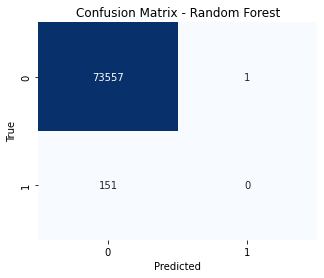


训练模型: Gradient Boosting
Accuracy : 0.9972
Precision: 0.0182
Recall   : 0.0066
F1-score : 0.0097
AUC      : 0.6350

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     73558
           1       0.02      0.01      0.01       151

    accuracy                           1.00     73709
   macro avg       0.51      0.50      0.50     73709
weighted avg       1.00      1.00      1.00     73709



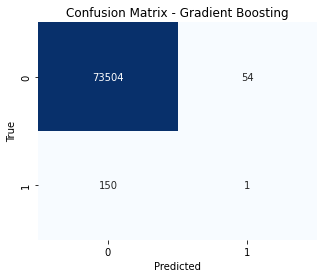


训练模型: Logistic Regression
Accuracy : 0.9980
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000
AUC      : 0.6366

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     73558
           1       0.00      0.00      0.00       151

    accuracy                           1.00     73709
   macro avg       0.50      0.50      0.50     73709
weighted avg       1.00      1.00      1.00     73709



/home/zhonghaoliang/anaconda3/envs/nida/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1327: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/zhonghaoliang/anaconda3/envs/nida/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1327: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/zhonghaoliang/anaconda3/envs/nida/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1327: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/

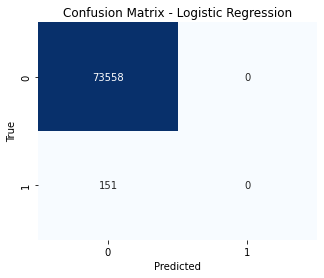


训练模型: SVM (RBF)
Accuracy : 0.9979
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000
AUC      : 0.5581

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     73558
           1       0.00      0.00      0.00       151

    accuracy                           1.00     73709
   macro avg       0.50      0.50      0.50     73709
weighted avg       1.00      1.00      1.00     73709



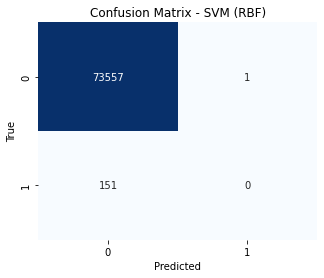


训练模型: AdaBoost
Accuracy : 0.9980
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000
AUC      : 0.6517

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     73558
           1       0.00      0.00      0.00       151

    accuracy                           1.00     73709
   macro avg       0.50      0.50      0.50     73709
weighted avg       1.00      1.00      1.00     73709



/home/zhonghaoliang/anaconda3/envs/nida/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1327: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/zhonghaoliang/anaconda3/envs/nida/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1327: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/zhonghaoliang/anaconda3/envs/nida/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1327: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/

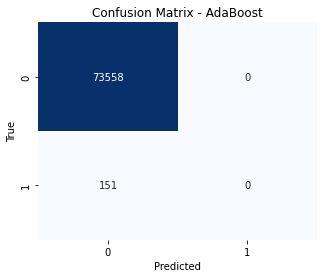


模型性能汇总对比
                     Accuracy  Precision  Recall  F1-score     AUC
Random Forest          0.9979     0.0000  0.0000    0.0000  0.6731
Gradient Boosting      0.9972     0.0182  0.0066    0.0097  0.6350
Logistic Regression    0.9980     0.0000  0.0000    0.0000  0.6366
SVM (RBF)              0.9979     0.0000  0.0000    0.0000  0.5581
AdaBoost               0.9980     0.0000  0.0000    0.0000  0.6517


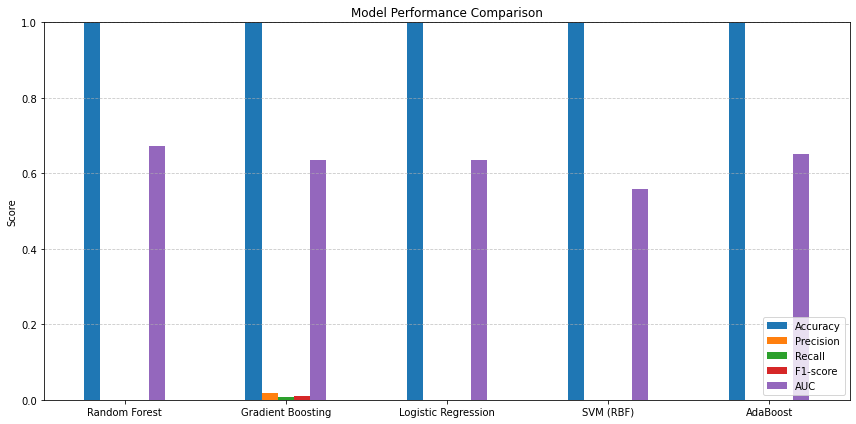

In [208]:

results = {}

for name, clf in models.items():
    print(f"\n{'='*40}\n训练模型: {name}\n{'='*40}")
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    # 对于SVM，需要概率来算AUC
    if hasattr(clf, "predict_proba"):
        y_pred_proba = clf.predict_proba(X_test)[:, 1]
    else:
        # SVM概率需要probability=True，已设置，但以防备用
        y_pred_proba = clf.decision_function(X_test)
        y_pred_proba = (y_pred_proba - y_pred_proba.min()) / (y_pred_proba.max() - y_pred_proba.min())
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'AUC': auc
    }
    
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"AUC      : {auc:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# ---------- 6. summary ----------
print("\n" + "="*60)
print("模型性能汇总对比")
print("="*60)
results_df = pd.DataFrame(results).T
print(results_df.round(4))

# visual
results_df.plot(kind='bar', figsize=(12,6), rot=0)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# save data

In [216]:
np.save('X.npy',X)
np.save('y.npy',y)